In [2]:
import os
import glob
import pandas as pd

In [3]:
# Fusion des datasets 
fichiers = glob.glob(os.path.join("Donnees/*.csv"))
fichiers

['Donnees\\Sales_December_2019.csv',
 'Donnees\\Sales_November_2019.csv',
 'Donnees\\Sales_October_2019.csv']

In [4]:
# Ajouter les elements du data frame dans une liste
lste_df = []
for f in sorted(fichiers):
    temp_df = pd.read_csv(f)
    # temp_df["source_fichier"] = os.path.basename(f)
    lste_df.append(temp_df)    
    print(f" {os.path.basename(f)} - {temp_df.shape[0]} ")

 Sales_December_2019.csv - 25117 
 Sales_November_2019.csv - 17661 
 Sales_October_2019.csv - 20379 


In [5]:
data = pd.concat(lste_df, ignore_index=True)
print(f"Nombre de ligne {data.shape[0]} et de colonne {data.shape[1]} ")

Nombre de ligne 63157 et de colonne 6 


In [6]:
data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,295665,Macbook Pro Laptop,1,1700,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.0,12/29/19 07:03,"562 2nd St, New York City, NY 10001"
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001"
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016"
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301"


In [7]:
# Modifier le nom des colonnes du data set
data.rename(columns={
    'Product' : 'Produit', 
    'Quantity Ordered' : 'Quantite',
    'Price Each' : 'Prix', 
    'Order Date' : 'Date', 
    'Purchase Address' : 'Adresse'} , inplace=True)

# Afficher le resultat
data.head()

,Order ID,Produit,Quantite,Prix,Date,Adresse
0,295665,Macbook Pro Laptop,1,1700,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.0,12/29/19 07:03,"562 2nd St, New York City, NY 10001"
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001"
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016"
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301"


In [8]:
data.dtypes

Order ID    str
Produit     str
Quantite    str
Prix        str
Date        str
Adresse     str
dtype: object

In [9]:
# Statistique descriptive des données du dataset
data.describe(include="all")

,Order ID,Produit,Quantite,Prix,Date,Adresse
count,62970,62970,62970,62970,62970,62970
unique,60314,20,9,24,45349,55450
top,Order ID,USB-C Charging Cable,1,11.95,Order Date,Purchase Address
freq,117,7486,57036,7486,117,117


In [10]:
# Afficher les doublons dans les données
print(f"Le nombre de doublon dans le dataset : {data.duplicated().sum()}")

Le nombre de doublon dans le dataset : 404


In [11]:
# Les valeurs manquantes 
data.isnull().sum()

Order ID    187
Produit     187
Quantite    187
Prix        187
Date        187
Adresse     187
dtype: int64

In [12]:
# Nettoyage des données
# Afficher la taille du dataset avant le nettoyage
before_clean = data.shape
before_clean

(63157, 6)

In [13]:
# Afficher les produits ayant le même Order ID
data.groupby('Order ID')['Produit'].apply(list)

Order ID
259358                               [34in Ultrawide Monitor]
259359                               [27in 4K Gaming Monitor]
259360                               [AAA Batteries (4-pack)]
259361                                     [27in FHD Monitor]
259362                                     [Wired Headphones]
                                  ...                        
319667                                [AA Batteries (4-pack)]
319668                                      [Vareebadd Phone]
319669                                     [Wired Headphones]
319670                           [Bose SoundSport Headphones]
Order ID    [Product, Product, Product, Product, Product, ...
Name: Produit, Length: 60314, dtype: object

In [14]:
# Supprimer les en-tête sur les lignes qui se repètent
data = data[data['Order ID'] != 'Order ID'].copy()
data.head()

,Order ID,Produit,Quantite,Prix,Date,Adresse
0,295665,Macbook Pro Laptop,1,1700,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.0,12/29/19 07:03,"562 2nd St, New York City, NY 10001"
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001"
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016"
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301"


In [15]:
# Supprimer les lignes entierement vide
data.dropna(subset=['Order ID'], inplace=True)

In [16]:
data.shape

(62853, 6)

In [17]:
# Suppression des doublons
data.drop_duplicates(inplace=True)

In [18]:
data.shape

(62751, 6)

In [19]:
# Conversion de Prix et Quantité en numérique
data['Quantite'] = pd.to_numeric(data['Quantite'], errors="coerce")

In [20]:
data['Prix'] = pd.to_numeric(data['Prix'], errors="coerce")

In [21]:
data.dtypes

Order ID        str
Produit         str
Quantite      int64
Prix        float64
Date            str
Adresse         str
dtype: object

In [23]:
# Convertir la colonne Date en date
data['Date'] = pd.to_datetime(data['Date'], errors="coerce")  

In [ ]:
# Conversion de la date
data['Date'] = pd.to_datetime(data['Date'], format="%m/%d/%y %H:%M", errors="coerce")
data.head()

In [24]:
data.dtypes

Order ID               str
Produit                str
Quantite             int64
Prix               float64
Date        datetime64[us]
Adresse                str
dtype: object

In [25]:
data.shape

(62751, 6)

In [ ]:
# Suppression des NaN
# data.dropna(subset=['Produit', 'Quantite', 'Prix'], inplace=True)

In [26]:
# Extraction des features temporelles
data['Date_n']     = data['Date'].dt.date

In [27]:
data.head()

,Order ID,Produit,Quantite,Prix,Date,Adresse,Date_n
0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",2019-12-30
1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",2019-12-29
2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",2019-12-12
3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",2019-12-22
4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",2019-12-18


In [28]:
# Afficher le nom des mois 
data['Nom_Mois'] = data['Date'].dt.strftime('%b')

In [29]:
# Afficher l'heure complete d'achat des produit
data['Heure'] = data['Date'].dt.strftime('%H:%M')

In [30]:
# Afficher les jours de la semaine
data['Jour_Semaine'] = data['Date'].dt.day_name()

In [31]:
data.head()

,Order ID,Produit,Quantite,Prix,Date,Adresse,Date_n,Nom_Mois,Heure,Jour_Semaine
0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",2019-12-30,Dec,00:01,Monday
1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",2019-12-29,Dec,07:03,Sunday
2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",2019-12-12,Dec,18:21,Thursday
3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",2019-12-22,Dec,15:13,Sunday
4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",2019-12-18,Dec,12:38,Wednesday


In [32]:
# Suppression de Date et prder id

data.drop(columns=['Order ID', 'Date'], inplace=True)

In [33]:
data.head()

,Produit,Quantite,Prix,Adresse,Date_n,Nom_Mois,Heure,Jour_Semaine
0,Macbook Pro Laptop,1,1700.00,"136 Church St, New York City, NY 10001",2019-12-30,Dec,00:01,Monday
1,LG Washing Machine,1,600.00,"562 2nd St, New York City, NY 10001",2019-12-29,Dec,07:03,Sunday
2,USB-C Charging Cable,1,11.95,"277 Main St, New York City, NY 10001",2019-12-12,Dec,18:21,Thursday
3,27in FHD Monitor,1,149.99,"410 6th St, San Francisco, CA 94016",2019-12-22,Dec,15:13,Sunday
4,USB-C Charging Cable,1,11.95,"43 Hill St, Atlanta, GA 30301",2019-12-18,Dec,12:38,Wednesday


In [34]:
# Extraction des features géographiques
data['Ville'] = data['Adresse'].str.split(",").str[1].str.strip()
# data['Etat']  = data['Adresse'].str.split(",").str[2].str.strip().str[2:]

In [35]:
data.head()

,Produit,Quantite,Prix,Adresse,Date_n,Nom_Mois,Heure,Jour_Semaine,Ville
0,Macbook Pro Laptop,1,1700.00,"136 Church St, New York City, NY 10001",2019-12-30,Dec,00:01,Monday,New York City
1,LG Washing Machine,1,600.00,"562 2nd St, New York City, NY 10001",2019-12-29,Dec,07:03,Sunday,New York City
2,USB-C Charging Cable,1,11.95,"277 Main St, New York City, NY 10001",2019-12-12,Dec,18:21,Thursday,New York City
3,27in FHD Monitor,1,149.99,"410 6th St, San Francisco, CA 94016",2019-12-22,Dec,15:13,Sunday,San Francisco
4,USB-C Charging Cable,1,11.95,"43 Hill St, Atlanta, GA 30301",2019-12-18,Dec,12:38,Wednesday,Atlanta


In [36]:
# Supprimer Adresse
data.drop(columns=['Adresse'], inplace=True)
data.head()

,Produit,Quantite,Prix,Date_n,Nom_Mois,Heure,Jour_Semaine,Ville
0,Macbook Pro Laptop,1,1700.00,2019-12-30,Dec,00:01,Monday,New York City
1,LG Washing Machine,1,600.00,2019-12-29,Dec,07:03,Sunday,New York City
2,USB-C Charging Cable,1,11.95,2019-12-12,Dec,18:21,Thursday,New York City
3,27in FHD Monitor,1,149.99,2019-12-22,Dec,15:13,Sunday,San Francisco
4,USB-C Charging Cable,1,11.95,2019-12-18,Dec,12:38,Wednesday,Atlanta


In [37]:
data.dtypes

Produit             str
Quantite          int64
Prix            float64
Date_n           object
Nom_Mois            str
Heure               str
Jour_Semaine        str
Ville            object
dtype: object

In [38]:
# Modifier une fois de plus la date_n
data['Date_n'] = pd.to_datetime(data['Date_n'], format="%m/%d/%y", errors="coerce")
data.head()

,Produit,Quantite,Prix,Date_n,Nom_Mois,Heure,Jour_Semaine,Ville
0,Macbook Pro Laptop,1,1700.00,2019-12-30,Dec,00:01,Monday,New York City
1,LG Washing Machine,1,600.00,2019-12-29,Dec,07:03,Sunday,New York City
2,USB-C Charging Cable,1,11.95,2019-12-12,Dec,18:21,Thursday,New York City
3,27in FHD Monitor,1,149.99,2019-12-22,Dec,15:13,Sunday,San Francisco
4,USB-C Charging Cable,1,11.95,2019-12-18,Dec,12:38,Wednesday,Atlanta


In [39]:
# Produits les plus vendu
quantite_vendue = (
    data.groupby("Produit")["Quantite"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

quantite_vendue.columns = ["Produit", "Quantité vendue"]

quantite_vendue.head(10)

,Produit,Quantité vendue
0,AAA Batteries (4-pack),10616
1,AA Batteries (4-pack),9280
2,USB-C Charging Cable,8161
3,Lightning Charging Cable,7855
4,Wired Headphones,6941
5,Apple Airpods Headphones,5255
6,Bose SoundSport Headphones,4531
7,27in FHD Monitor,2472
8,iPhone,2288
9,27in 4K Gaming Monitor,2159


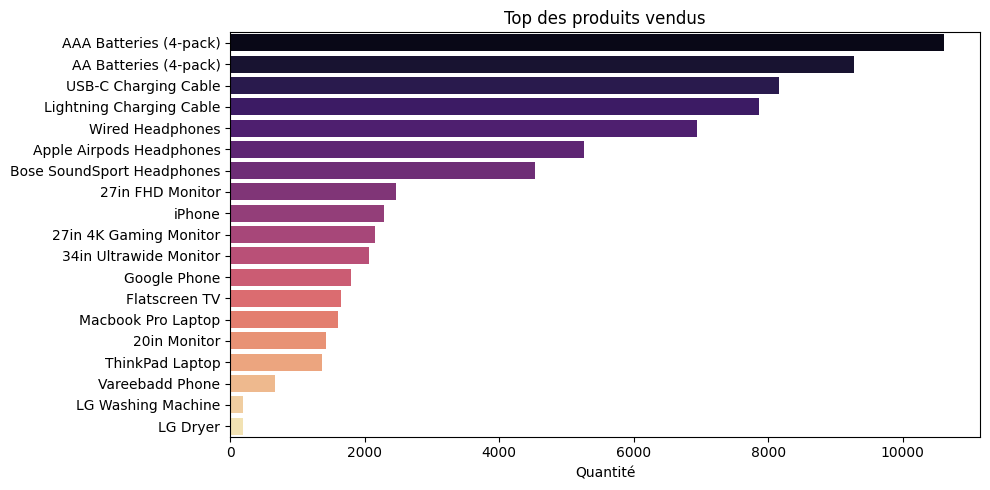

In [40]:
# Import des modules
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(figsize=(10,5))
sns.barplot(data   = quantite_vendue, 
            x      = "Quantité vendue", 
            y      = "Produit",
            hue    = "Produit",
           palette ="magma",
            ax     = axes)
axes.set_title("Top des produits vendus")
axes.set_xlabel("Quantité")
axes.set_ylabel("")

plt.tight_layout()

plt.show()

In [41]:
# Ventes realisées par jour
data["CA_Jour"] = data["Quantite"] * data["Prix"]
data.head()

,Produit,Quantite,Prix,Date_n,Nom_Mois,Heure,Jour_Semaine,Ville,CA_Jour
0,Macbook Pro Laptop,1,1700.00,2019-12-30,Dec,00:01,Monday,New York City,1700.00
1,LG Washing Machine,1,600.00,2019-12-29,Dec,07:03,Sunday,New York City,600.00
2,USB-C Charging Cable,1,11.95,2019-12-12,Dec,18:21,Thursday,New York City,11.95
3,27in FHD Monitor,1,149.99,2019-12-22,Dec,15:13,Sunday,San Francisco,149.99
4,USB-C Charging Cable,1,11.95,2019-12-18,Dec,12:38,Wednesday,Atlanta,11.95


In [42]:
# Sommes des ventes groupées par mois
ca_par_mois = data.groupby(data["Nom_Mois"])["CA_Jour"].sum()
ca_par_mois

Nom_Mois
Dec    4608295.70
Jan       8670.29
Nov    3197875.05
Oct    3731424.55
Name: CA_Jour, dtype: float64

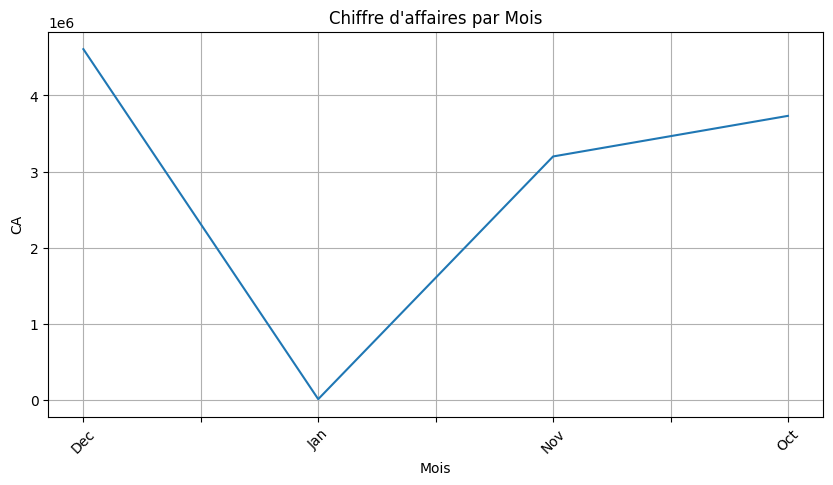

In [43]:
# Aperçu du chiffre d'affaire par mois
plt.figure(figsize=(10,5))
ca_par_mois.plot()
plt.title("Chiffre d'affaires par Mois")
plt.xlabel("Mois")
plt.ylabel("CA")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [45]:
# Rgrouper et compter les differentes commandes faites par ville
data.groupby('Ville')['Ville'].count()

Ville
Atlanta           4996
Austin            3301
Boston            6783
Dallas            5005
Los Angeles       9922
New York City     8405
Portland          4191
San Francisco    15078
Seattle           5070
Name: Ville, dtype: int64

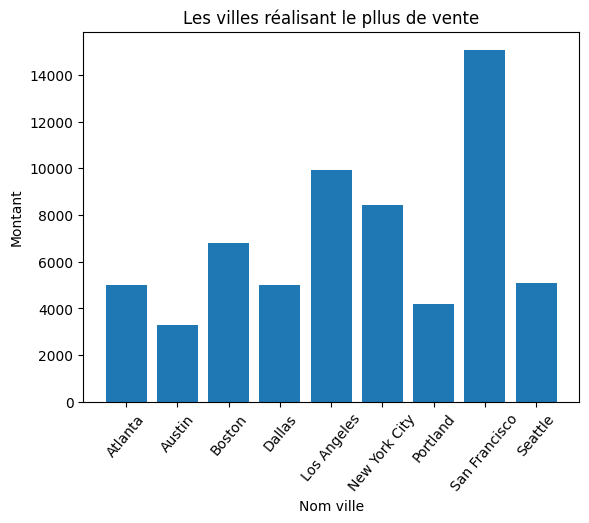

In [46]:
# Visuel pour mieux voir les villes qui realise le plus de commande
plt.bar(data.groupby('Ville')['Ville'].count().index,data.groupby('Ville')['Ville'].count().values)
plt.xticks(rotation=50)
plt.title("Les villes réalisant le pllus de vente")
plt.ylabel('Montant')
plt.xlabel('Nom ville')
plt.show()

### Définir le moment où l'on doit créer une campagne publicitaire


In [47]:
data.head()

,Produit,Quantite,Prix,Date_n,Nom_Mois,Heure,Jour_Semaine,Ville,CA_Jour
0,Macbook Pro Laptop,1,1700.00,2019-12-30,Dec,00:01,Monday,New York City,1700.00
1,LG Washing Machine,1,600.00,2019-12-29,Dec,07:03,Sunday,New York City,600.00
2,USB-C Charging Cable,1,11.95,2019-12-12,Dec,18:21,Thursday,New York City,11.95
3,27in FHD Monitor,1,149.99,2019-12-22,Dec,15:13,Sunday,San Francisco,149.99
4,USB-C Charging Cable,1,11.95,2019-12-18,Dec,12:38,Wednesday,Atlanta,11.95


In [48]:
keys = []
hours = []

# Regrouper les commandes par heure
for key, hour in data.groupby('Heure'):
    keys.append(key)
    hours.append(hour)
    
hours

[                          Produit  Quantite    Prix     Date_n Nom_Mois  \
 3262   Bose SoundSport Headphones         1   99.99 2019-12-19      Dec   
 3366       34in Ultrawide Monitor         1  379.99 2019-12-31      Dec   
 3745     Lightning Charging Cable         1   14.95 2019-12-08      Dec   
 4089     Lightning Charging Cable         1   14.95 2019-12-05      Dec   
 6548       AAA Batteries (4-pack)         1    2.99 2019-12-11      Dec   
 6811             Wired Headphones         1   11.99 2019-12-31      Dec   
 6963                 Google Phone         1  600.00 2019-12-04      Dec   
 7021       34in Ultrawide Monitor         1  379.99 2019-12-07      Dec   
 8882         USB-C Charging Cable         2   11.95 2019-12-31      Dec   
 11641                      iPhone         1  700.00 2019-12-10      Dec   
 14437            27in FHD Monitor         1  149.99 2019-12-27      Dec   
 25616  Bose SoundSport Headphones         1   99.99 2019-11-03      Nov   
 26401    Li

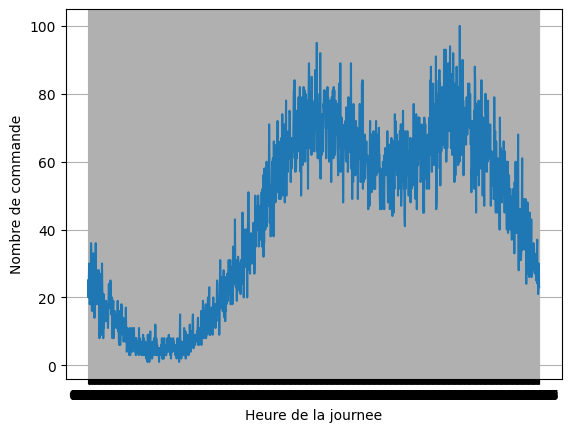

In [49]:
# Transformer hours en taille sinon on lève un Attribute Error
counts = [len(h) for h in hours]

# Visualisation  
plt.grid()
plt.plot(keys, counts)
plt.xlabel('Heure de la journee')
plt.ylabel('Nombre de commande')
plt.show()

<Axes: xlabel='Produit'>

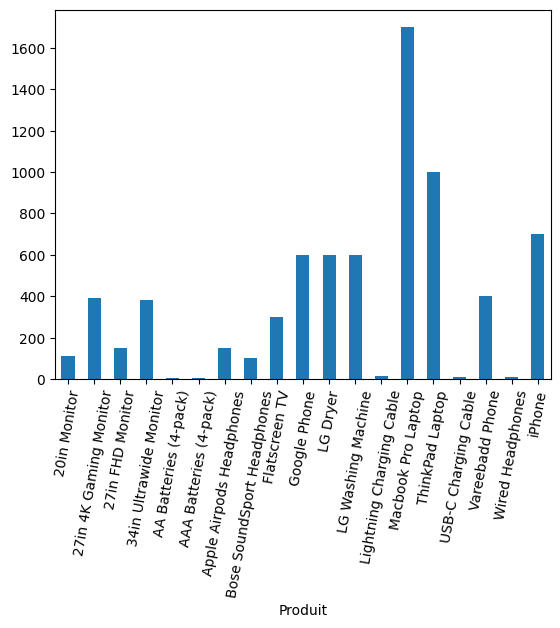

In [50]:
# influence du prix sur les produits commmandés
data.groupby('Produit')['Prix'].mean().plot(kind='bar', rot=80)

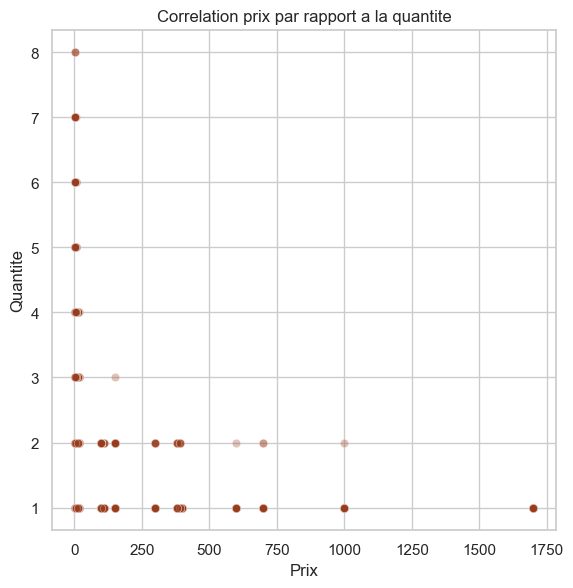

In [51]:
# Monntrer la correlation du prix par rapport a la quantite
import seaborn as sns

# Délarer l'affichage de notre graphique
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(6.5, 6.5))

sns.scatterplot(data=data, x="Prix", y="Quantite", 
               alpha=0.3, ax=ax, color='#993C1D')
ax.set_title("Correlation prix par rapport a la quantite")
ax.set_xlabel('Prix')
ax.set_ylabel('Quantite')

plt.show()

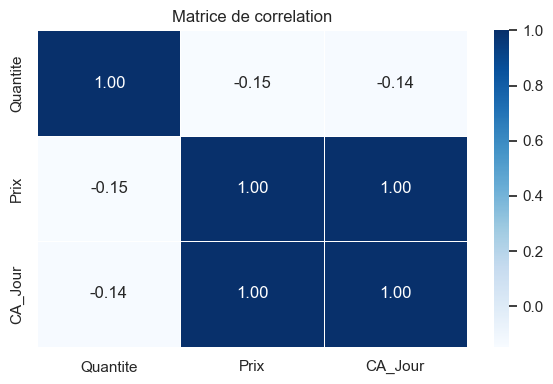

In [52]:
# Matrice de correlation
correlation = data[['Quantite', 'Prix', 'CA_Jour']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, fmt=".2f",
            cmap="Blues", linewidths=0.6)
plt.title("Matrice de correlation")
plt.tight_layout()
plt.show()

In [53]:
data

,Produit,Quantite,Prix,Date_n,Nom_Mois,Heure,Jour_Semaine,Ville,CA_Jour
0,Macbook Pro Laptop,1,1700.00,2019-12-30,Dec,00:01,Monday,New York City,1700.00
1,LG Washing Machine,1,600.00,2019-12-29,Dec,07:03,Sunday,New York City,600.00
2,USB-C Charging Cable,1,11.95,2019-12-12,Dec,18:21,Thursday,New York City,11.95
3,27in FHD Monitor,1,149.99,2019-12-22,Dec,15:13,Sunday,San Francisco,149.99
4,USB-C Charging Cable,1,11.95,2019-12-18,Dec,12:38,Wednesday,Atlanta,11.95
...,...,...,...,...,...,...,...,...,...
63152,AA Batteries (4-pack),1,3.84,2019-10-12,Oct,04:32,Saturday,San Francisco,3.84
63153,Wired Headphones,1,11.99,2019-10-28,Oct,22:00,Monday,Los Angeles,11.99
63154,AA Batteries (4-pack),1,3.84,2019-10-09,Oct,20:58,Wednesday,San Francisco,3.84
63155,iPhone,1,700.00,2019-10-31,Oct,17:21,Thursday,Seattle,700.00


In [54]:
data.to_csv('data_cleaned.csv', index=False)

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv('data_cleaned.csv')
data.head()

,Produit,Quantite,Prix,Date_n,Nom_Mois,Heure,Jour_Semaine,Ville,CA_Jour
0,Macbook Pro Laptop,1,1700.00,2019-12-30,Dec,00:01,Monday,New York City,1700.00
1,LG Washing Machine,1,600.00,2019-12-29,Dec,07:03,Sunday,New York City,600.00
2,USB-C Charging Cable,1,11.95,2019-12-12,Dec,18:21,Thursday,New York City,11.95
3,27in FHD Monitor,1,149.99,2019-12-22,Dec,15:13,Sunday,San Francisco,149.99
4,USB-C Charging Cable,1,11.95,2019-12-18,Dec,12:38,Wednesday,Atlanta,11.95


In [17]:
# Code de claude 
import pandas as pd
import hashlib

def generer_sigle(nom_produit, sigles_existants):
    mots = nom_produit.upper().split()
    if len(mots) >= 2:
        sigle = mots[0][0] + mots[1][0] 
    else:
        sigle = mots[0][:3]
    
    sigle_original = sigle
    compteur = 1
    while sigle in sigles_existants.values():
        sigle = sigle_original[:2] + str(compteur)
        compteur += 1
    return sigle

def generer_numero_stable(nom_produit):
    """Génère un numéro à 3 chiffres stable basé sur le hash du nom."""
    hash_val = int(hashlib.md5(nom_produit.encode()).hexdigest(), 16)
    return str(hash_val % 900 + 100)  # Toujours entre 100 et 999

# Générer les IDs stables
produits_uniques = data['Produit'].unique()
sigles_map = {}
product_ids = {}

for produit in produits_uniques:
    sigle = generer_sigle(produit, sigles_map)
    sigles_map[produit] = sigle
    numero = generer_numero_stable(produit)
    product_ids[produit] = f"{sigle}-{numero}"

data['Produit_ID'] = data['Produit'].map(product_ids)

print(data[['Produit', 'Produit_ID']].drop_duplicates())

                        Produit Produit_ID
0            Macbook Pro Laptop     MP-135
1            LG Washing Machine     LW-984
2          USB-C Charging Cable     UC-850
3              27in FHD Monitor     2F-266
5         AA Batteries (4-pack)     AB-620
8    Bose SoundSport Headphones     BS-645
9        AAA Batteries (4-pack)    AB1-794
11              ThinkPad Laptop     TL-622
15     Lightning Charging Cable     LC-139
16                 Google Phone     GP-592
19             Wired Headphones     WH-132
25     Apple Airpods Headphones     AA-926
36              Vareebadd Phone     VP-458
54                       iPhone    IPH-741
56                 20in Monitor     2M-857
61       34in Ultrawide Monitor     3U-195
89                Flatscreen TV     FT-742
143      27in 4K Gaming Monitor     24-921
744                    LG Dryer     LD-175


In [18]:
data.head()

,Produit_ID,Produit,Ville,Date_n,Nom_Mois,Jour_Semaine,Heure,Quantite,Prix,CA_Jour
0,MP-135,Macbook Pro Laptop,New York City,2019-12-30,Dec,Monday,00:01,1,1700.00,1700.00
1,LW-984,LG Washing Machine,New York City,2019-12-29,Dec,Sunday,07:03,1,600.00,600.00
2,UC-850,USB-C Charging Cable,New York City,2019-12-12,Dec,Thursday,18:21,1,11.95,11.95
3,2F-266,27in FHD Monitor,San Francisco,2019-12-22,Dec,Sunday,15:13,1,149.99,149.99
4,UC-850,USB-C Charging Cable,Atlanta,2019-12-18,Dec,Wednesday,12:38,1,11.95,11.95


In [19]:
data.groupby('Produit_ID')['Produit'].apply(list)

Produit_ID
24-921     [27in 4K Gaming Monitor, 27in 4K Gaming Monito...
2F-266     [27in FHD Monitor, 27in FHD Monitor, 27in FHD ...
2M-857     [20in Monitor, 20in Monitor, 20in Monitor, 20i...
3U-195     [34in Ultrawide Monitor, 34in Ultrawide Monito...
AA-926     [Apple Airpods Headphones, Apple Airpods Headp...
AB-620     [AA Batteries (4-pack), AA Batteries (4-pack),...
AB1-794    [AAA Batteries (4-pack), AAA Batteries (4-pack...
BS-645     [Bose SoundSport Headphones, Bose SoundSport H...
FT-742     [Flatscreen TV, Flatscreen TV, Flatscreen TV, ...
GP-592     [Google Phone, Google Phone, Google Phone, Goo...
IPH-741    [iPhone, iPhone, iPhone, iPhone, iPhone, iPhon...
LC-139     [Lightning Charging Cable, Lightning Charging ...
LD-175     [LG Dryer, LG Dryer, LG Dryer, LG Dryer, LG Dr...
LW-984     [LG Washing Machine, LG Washing Machine, LG Wa...
MP-135     [Macbook Pro Laptop, Macbook Pro Laptop, Macbo...
TL-622     [ThinkPad Laptop, ThinkPad Laptop, ThinkPad La...
UC-850     [U

In [16]:
# Chatgpt code

# Charger ton dataset
data = pd.read_csv("data_cleaned.csv")

# Nouvel ordre des colonnes
nouvel_ordre = [
    "Produit_ID", "Produit", "Ville", "Date_n",
    "Nom_Mois", "Jour_Semaine", "Heure",
    "Quantite", "Prix", "CA_Jour"
]

data = data[nouvel_ordre]

print(data.head())

  Produit_ID               Produit          Ville      Date_n Nom_Mois  \
0    MPL-001    Macbook Pro Laptop  New York City  2019-12-30      Dec   
1    LWM-002    LG Washing Machine  New York City  2019-12-29      Dec   
2    UCC-003  USB-C Charging Cable  New York City  2019-12-12      Dec   
3    2FM-004      27in FHD Monitor  San Francisco  2019-12-22      Dec   
4    UCC-003  USB-C Charging Cable        Atlanta  2019-12-18      Dec   

  Jour_Semaine  Heure  Quantite     Prix  CA_Jour  
0       Monday  00:01         1  1700.00  1700.00  
1       Sunday  07:03         1   600.00   600.00  
2     Thursday  18:21         1    11.95    11.95  
3       Sunday  15:13         1   149.99   149.99  
4    Wednesday  12:38         1    11.95    11.95  


In [20]:
data.to_csv('sales_three_month_cleaned.csv', index=False)